<a href="https://colab.research.google.com/github/alankrithaa/alankrithaa.github.io/blob/main/gasp_govtech_THA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Basic analysis of dataset**

In [ ]:
pip install pandas matplotlib seaborn wordcloud

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
df = pd.read_csv('DataSet.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   location             17534 non-null  object
 2   department           6333 non-null   object
 3   salary_range         2868 non-null   object
 4   company_profile      14572 non-null  object
 5   description          17880 non-null  object
 6   requirements         15191 non-null  object
 7   benefits             10684 non-null  object
 8   telecommuting        17880 non-null  object
 9   has_company_logo     17880 non-null  object
 10  has_questions        17880 non-null  object
 11  employment_type      14409 non-null  object
 12  required_experience  10830 non-null  object
 13  required_education   9775 non-null   object
 14  industry             12977 non-null  object
 15  function             11425 non-null  object
 16  frau

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbr...","<p>Food52, a fast-growing, James Beard Award-w...",<ul>\r\n<li>Experience with content management...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,f
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Product...",<p>Organised - Focused - Vibrant - Awesome!<br...,<p><b>What we expect from you:</b></p>\r\n<p>Y...,<h3><b>What you will get from us</b></h3>\r\n<...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,f
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workfo...,"<p>Our client, located in Houston, is actively...",<ul>\r\n<li>Implement pre-commissioning and co...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life t...,<p><b>THE COMPANY: ESRI – Environmental System...,<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s o...,<p>Our culture is anything but corporate—we ha...,f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,f
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,<p>SpotSource Solutions LLC is a Global Human ...,<p><b>JOB TITLE:</b> Itemization Review Manage...,<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>R...,<p>Full Benefits Offered</p>,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,f


**Key findings from above output (initial dataset exploration)**

- 18 columns
- 17880 job listings (pretty rich and large dataset)
- Each row is one job advertisement, structure of dataset is easy to understand

Feature diversity is really good, varying from basics (Job description, requirements) to more specific (company logo presence, employment type, experience level required)


**Limitations of the dataset**

1) Based on the non-null count of each feature, it's seen that many columns are quite incomplete, such as:
- Salary range
- Department
- Benefits
- Required education

2) Binary and categorical variables are also stored as text, which can lead to inaccuracy in some cases.

3) Limited external context - this could be pretty useful for finding fraud (Like user behaviour, company history, timestamps)





**Most useful features for distinguishing (scam vs real)** - a simple assumption before actual analysis

- **company profile** - for a quick background check
- **description, industry, function, location** - it could be suspicious when it's very vague, maybe just buzzwords used, no real tasks listed or place stated
- **requirements, required_experience, required_education** - scam jobs have higher chances of posting a very low, too good to be true entry barriers (work from home, no experience, earn per week etc)

- **benefits** - generally not proportionate to job, could be exaggerating to attract people to apply

- **has_company_logo** - a good feature, scam posts are more likely to have no company logo

- **has_questions** - scam posts may not have many questions (since they do not care about actual hiring)

features added like missing requirements, missing benefits, missing industry can be worth adding, as scammers may omit above details to stay vague, and the above can be easily filtered.

# **Recurring patterns analysis**

In [ ]:
#Standardizing column names
df.columns = df.columns.str.strip().str.lower()

#Convert t/f strings to 1/0 where relevant
tf_cols = ['telecommuting', 'has_company_logo', 'has_questions', 'fraudulent', 'in_balanced_dataset']
for col in tf_cols:
    if col in df.columns:
        df[col] = df[col].map({'t': 1, 'f': 0, '1': 1, '0': 0}).fillna(df[col])

#ensure target is numeric if possible
df['fraudulent'] = pd.to_numeric(df['fraudulent'], errors='coerce')

                     Legit (0)  Fraud (1)
salary_range         84.453979  74.249423
company_profile      15.992712  67.782910
department           64.746679  61.316397
required_education   44.986482  52.078522
required_experience  38.879746  50.230947
benefits             40.161044  41.916859
function             35.958622  38.914550
industry             27.201128  31.755196
employment_type      18.984366  27.829099
requirements         14.905372  17.667436
location              1.921947   2.193995


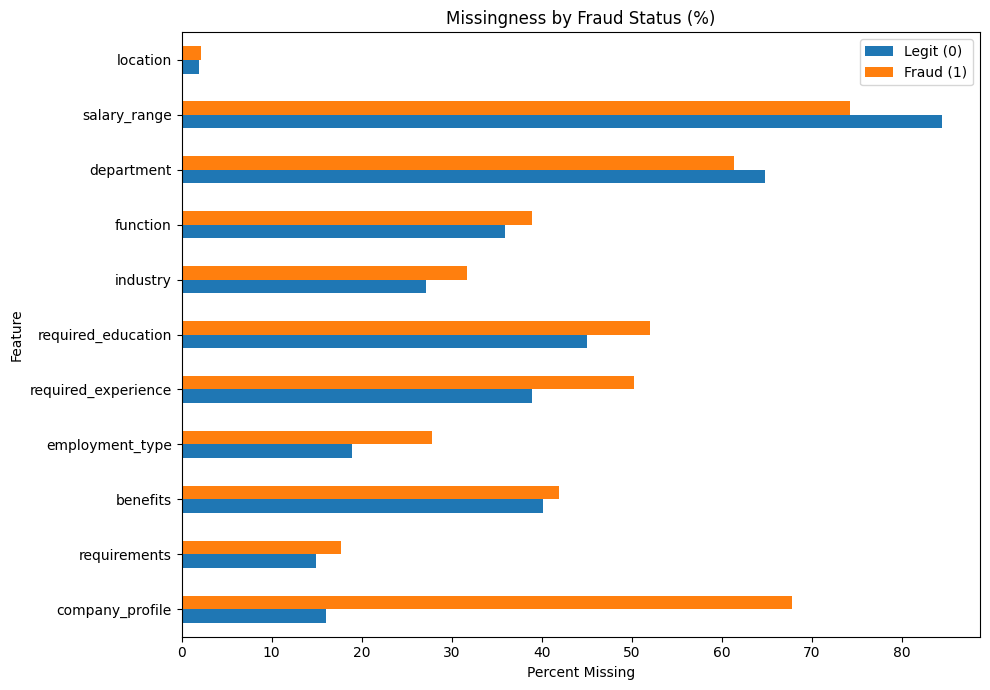

In [ ]:
cols_to_check = [
    'company_profile', 'requirements', 'benefits', 'employment_type',
    'required_experience', 'required_education', 'industry',
    'function', 'department', 'salary_range', 'location'
]

missing_by_fraud = (
    df.groupby('fraudulent')[cols_to_check]
      .apply(lambda x: x.isna().mean() * 100)
      .T
)

missing_by_fraud.columns = ['Legit (0)', 'Fraud (1)']
print(missing_by_fraud.sort_values('Fraud (1)', ascending=False))

missing_by_fraud.plot(kind='barh', figsize=(10, 7))
plt.title('Missingness by Fraud Status (%)')
plt.xlabel('Percent Missing')
plt.ylabel('Feature')
plt.tight_layout()
plt.show() #run this cell to see plot

The above shows percentage of missing values in each feature, split by legit vs fraud.
From the graph, it can be interpreted that if fraud rows have much higher missingness in a certain feature - it's a pretty strong signal that frauds may exhibit missingess in such fields.

For eg (Using a line of output from above)

company_profile     
Legit: 15.992712  
Fraud: 67.782910


This means that only ~16% of legit job ads are missing a company profile, but ~68% of scam ads are missing it.

           telecommuting  has_company_logo  has_questions
Legit (0)       4.131891         81.914894      50.205713
Fraud (1)       7.390300         32.678984      28.868360


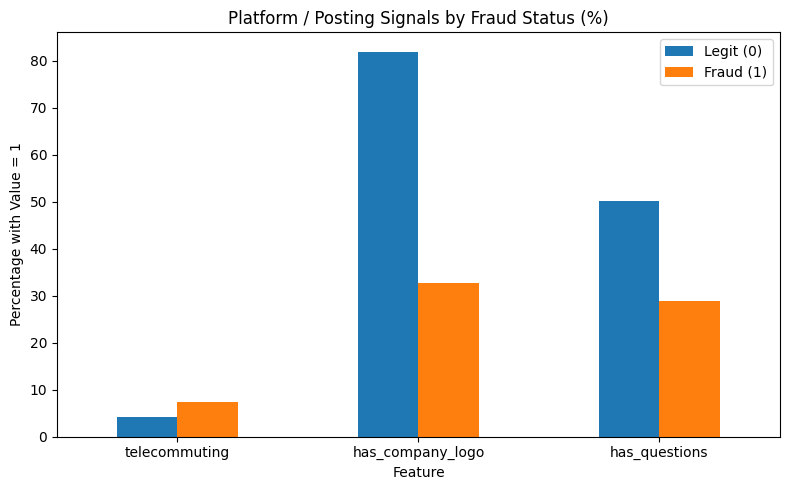

In [ ]:
binary_cols = ['telecommuting', 'has_company_logo', 'has_questions']

binary_summary = df.groupby('fraudulent')[binary_cols].mean() * 100
binary_summary.index = ['Legit (0)', 'Fraud (1)']
print(binary_summary)

binary_summary.T.plot(kind='bar', figsize=(8, 5))
plt.title('Platform / Posting Signals by Fraud Status (%)')
plt.ylabel('Percentage with Value = 1')
plt.xlabel('Feature')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The above shows % of posts where the feature is present/TRUE

Fraud posts are almost 2x likely (7.399%) to advertise remote work - to attract more applicants

Only 33% of fraud posts have company logos, whereas 82% of legit companies have logos.

Legit posts are much more likely to include screening questions.


           company_profile_wordcount  description_wordcount  \
Legit (0)                      101.3                  191.0   
Fraud (1)                       35.0                  174.3   

           requirements_wordcount  benefits_wordcount  
Legit (0)                    90.5                34.2  
Fraud (1)                    63.4                33.3  


<Figure size 1000x600 with 0 Axes>

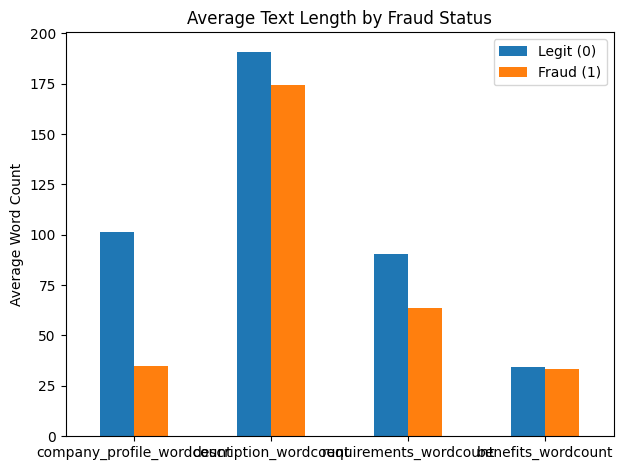

In [ ]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)        # remove HTML
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

text_cols = ['company_profile', 'description', 'requirements', 'benefits']

for col in text_cols:
    df[col + '_clean'] = df[col].apply(clean_text)
    df[col + '_wordcount'] = df[col + '_clean'].apply(lambda x: len(x.split()))

# --- Compare average length by fraud status ---
length_cols = [c + '_wordcount' for c in text_cols]

length_summary = df.groupby('fraudulent')[length_cols].mean().round(1)
length_summary.index = ['Legit (0)', 'Fraud (1)']
print(length_summary)

# --- Nice visual ---
plt.figure(figsize=(10,6))
length_summary.T.plot(kind='bar')
plt.title('Average Text Length by Fraud Status')
plt.ylabel('Average Word Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Fraud ads have shorter company profiles, shorter requirements & less detailed job info - it shows that they can be identified by lesser info depth and credibility.

Based on the above, it can be shown that fraud ads are less complete structurally (less info and important details), and tend to have fewer requirement details as well as transperancy about the company (logo, description etc)

# **Approach 1**

## **Overview of Approach 1**

**TF-IDF (Term Frequency-Inverse Document Frequency) + Logistic regression classifier.**

**TF-IDF** - converts text into numerical features by measuring importance of a word in a document. It is perfect for highlighting distinctive terms (common scam phrases), while downweighting common words.

**Logistic regression**: Best for estimating the probability of a binary outcome (In this case, fraud vs legitimate). It's extremely efficient, rather simple and well suited for high dimensional sparse text features like TF-IDF Vectors.

These ads often differ in language patterns. An NLP + ML approach enables automated detection of such textual signals, and also scale to large volumes of job postings.



## **Features of approach 1**

1) **Capturing text informativeness difference**:
Scam job posts tend to have shorter descriptions, and less detailed requirement.

   TF-IDF specifically targets such an issue, by:

- Quanitifying word importance within a document
- Highlighting rare but meaningful terms
- Downweighting common words (if/but/and and so on)

Logistic regression handles the sparse linear separability well. It also shows coefficients which terms increase fraud probability.

Below code is not runnable, but just a surface level view of implementing TF-IDF extraction.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000, #limits vocab to top 500 informative phrases/words
    ngram_range=(1,2),      #capture phrases (eg apply now, no experience)
    stop_words='english'
)

X_text = tfidf.fit_transform(df['combined_text']) #learns vocab from dataset, and transforms each job post into a numeric vector


It creates a TF-IDF Vectorizer, which reads texts, breaks it down into words/phrases and converts it into weighted numeric features.


2. **Capturing missing elements**

Fraudulent jobs, as seen in the EDA, often avoid traceability (company logo, background, description) and minimize effort.

- Logistic regression is ideal for such binary indicator features:

  - linear additive risk modeling (each missing element contributes independently to fraud risk)
  - weight interpretability (coefficients show how strongly each missing element increases fraud odds)




In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the binary credibility features
df['missing_company_profile'] = df['company_profile'].isna().astype(int)
df['missing_requirements'] = df['requirements'].isna().astype(int)
df['missing_education'] = df['required_education'].isna().astype(int)
df['no_company_logo'] = (1 - df['has_company_logo']).astype(int)
df['no_screening_questions'] = (1 - df['has_questions']).astype(int)

# Example binary credibility features
X_missing = df[[
    'missing_company_profile',
    'missing_requirements',
    'missing_education',
    'no_company_logo',
    'no_screening_questions'
]].astype(int)

y = df['fraudulent']

model = LogisticRegression(class_weight='balanced')
model.fit(X_missing, y)

LogisticRegression(class_weight='balanced')

The above code (a sample snippet)  shows that the model learns from missing patterns. Each column becomes a weighted fraud signal. There aren't any complex transformations required, and it's highly interpretable logic.

3. **Multi-modal learning**

Logistic regression combines individual signals into a unified probabilistic classifier, handling sparse text vectors & structured features together. It remains interpretable and deployable in the real world.



## **Dataset preparation**

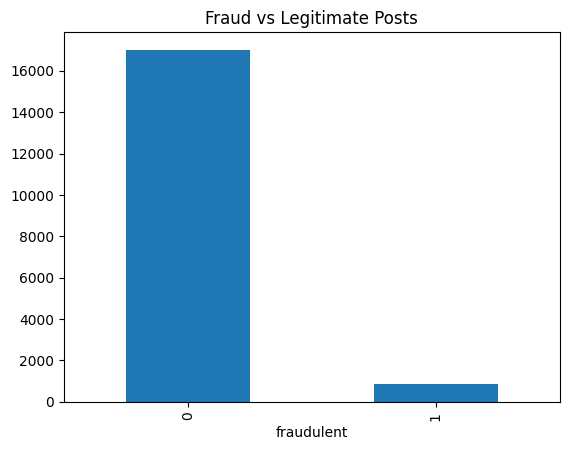

In [ ]:
df['fraudulent'].value_counts().plot(kind='bar')
plt.title('Fraud vs Legitimate Posts')
plt.show()

- Distribution of class is important to visualize initially when preparing data.

Fraudulent being rare affects the evaluation strategy to a large extent.



In [ ]:
df['combined_text'] = (
    df['description'].fillna('') + ' ' +
    df['requirements'].fillna('') + ' ' +
    df['company_profile'].fillna('')
)

Merging of key textual fields, ensures that the model sees dull narrative of every single jon posting. It's important as scam signs may appear across sections.

In [ ]:
import re

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', str(text))   # remove HTML
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # remove symbols
    return re.sub(r'\s+', ' ', text).lower().strip()

df['clean_text'] = df['combined_text'].apply(clean_text)

Text cleaning - removed HTML tags and markup from scraped listings, special characters stripped, standardized text by lowercasing & whitespace normalization.
This prevents noisy tokens from distorting actual language features.

In [ ]:
df['desc_len'] = df['description'].fillna('').str.split().str.len()
df['req_len']  = df['requirements'].fillna('').str.split().str.len()

Text informativeness features.

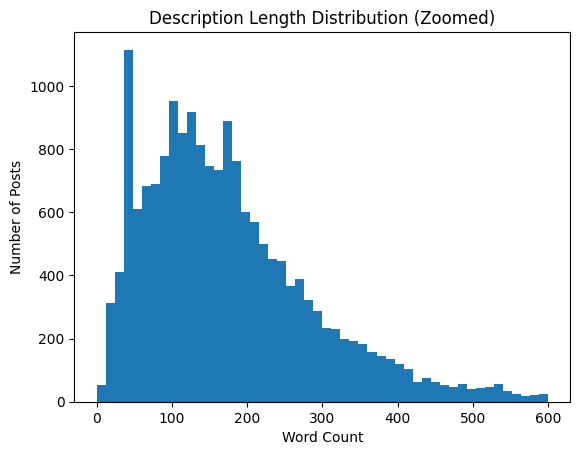

In [ ]:
plt.hist(df['desc_len'], bins=50, range=(0,600))
plt.title('Description Length Distribution (Zoomed)')
plt.xlabel('Word Count')
plt.ylabel('Number of Posts')
plt.show()

The above shows the length of job descriptions. From generated graph, it shows short vs medium vs long post, and the general spread.

We can interpret that many posts don't have a long word count, and are rather short and medium



In [ ]:
df['missing_company_profile'] = df['company_profile'].isna().astype(int)
df['missing_requirements']    = df['requirements'].isna().astype(int)
df['no_company_logo']         = (df['has_company_logo'] == 'f').astype(int)
df['no_questions']            = (df['has_questions'] == 'f').astype(int)
df['telecommuting_flag']      = (df['telecommuting'] == 't').astype(int)

From the EDA findings

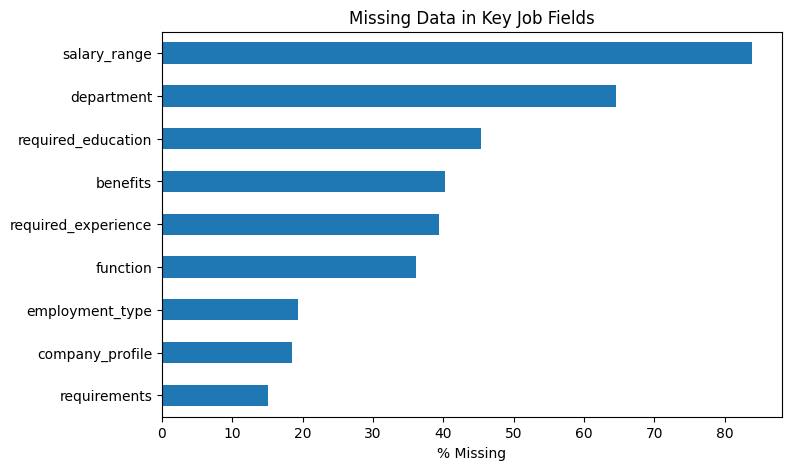

In [ ]:
orig_cols = [
    'salary_range','department','required_education','required_experience',
    'benefits','function','company_profile','employment_type','requirements'
]

missing_pct = df[orig_cols].isna().mean() * 100

missing_pct.sort_values().plot(kind='barh', figsize=(8,5))
plt.xlabel('% Missing')
plt.title('Missing Data in Key Job Fields')
plt.show()

Missingness overview plot.

It shows that the above features, in order have the most missing details.
Salary is rarely provided, department is missing, required education often missing etc.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_text = tfidf.fit_transform(df['clean_text'])

Text --> Numeric (TF-IDF) - important for implementing the model

In [ ]:
structured_cols = [
    'missing_company_profile',
    'missing_requirements',
    'no_company_logo',
    'no_questions',
    'telecommuting_flag',
    'desc_len',
    'req_len'
]

X_struct = df[structured_cols].values

Structured feature matrix (taking the numeric features, and bringing them into a table of numbers)

In [ ]:
from scipy.sparse import hstack
X = hstack([X_text, X_struct])

Final feature set
Combined:
- Text features
- Structured features

into one big feature matrix
 (model ready!)

In [ ]:
y = df['fraudulent'].astype(int)

Labels

## **Limitations & Challenges**

**- (Challenge) Extremely large scale data**: Considering that GovTech systems process extremely large datasets, it is an important aspect to consider. TF-IDF creates high-dimensional feature matrices that can become memory intensive.

To address this, batch training can be implemented. Additionally, vocab size can be limited. Implementing these two together would handle a lot of the challenges posted.


**- (Challenge) Evolving scam language**:
Scammers adapt fast to keep up with times. Their phrases change over time, may become strangely specific to look believable.

To address this, period model retraining is crucial. There can additionally be a hybrid system with rule flags, to be more vigilant.

**- (Limitation) TF-IDF captures word frequency, not true meaning.**

For instance, "not a scam" vs "scam" --> similar tokens.

It is important to include n-grams, upgrade to embeddings if needed to solve this issue.

## **Evaluation of model**

**1) Model Validation**

- Train/test split (most important), ensuring no data leakage for testing
- k-Fold Cross validation (splitting dataset into k equal parts, and the model to be train and tested k times using different folds)


**2) Reviewing by domain experts**

- A sample containing job postings should be reviewed by experts to verify if they exhibit scam characteristics.
It helps with confirming that flagged listings show actual scam indicators. Moreover, common model errors can be identified in case anything is incorrectly flagged.

**3) Pilot deployment**

The system with the proposed model can be gradually introduced through a controlled rollout. Job platforms that are currently less popular  can be prioritized first for the sake of testing, as a lower risk environment would let lesser legitimate employers affected (if any). It would be easier to monitor issues on a smaller platform at first as well.

After a controlled phase 1, depolyment can be done on a fraction of postings in a more major platform.



**4) Fairness checks**

Model performance would be assessed across different segments to ensure consistency and unbiasedness.

- Performance across industries
- Performance across job seniority levels
- Performance across companu profiles (eg startups vs large MNCs)

This is to prevent systematic over flagging of specific sectors or employer groups.

## **Metrics & Baseline**

In [ ]:
#eg code (commented out), requires test data
#from sklearn.metrics import precision_score
#precision_score(y_true, y_pred)

Precision matters the most, as it tells us how many are truly scam job ads.
A high precision means fewer legitimate employers wrongfully blocked.

In [ ]:
#from sklearn.metrics import recall_score
#recall_score(y_true, y_pred)

Recall score is another important metric to be considered. Higher recall --> fewer scams reaching the public.

In [ ]:
#from sklearn.metrics import f1_score
#f1_score(y_true, y_pred)

Accurate and good fraud detection needs to both catch scams, and also avoid harming actual employers.

**Baselines** - the goal is to beat simple systems first to show that a NLP + ML method is truly worth it.

Baselines to beat:

- Random guessing (assigning fraud randomly)
- Rule based Heuristic system (eg flags posts it missing certain feature)


# **Approach 2**

### **Overview of Approach 2**

**Cross-Field consistency model**

The main idea of this model is to detect whether different fields within jobs are consistent, and make sense together.

Examples of inconsistency that this approach aims to catch:
- A "Manager" role requiring no experience.
- A highly technical role with no technical skills mentioned under requirements.
- A "remote" position with immediate start and high pay combination.

Scammers often imitate individual parts of a real ad, but they fail to maintain consistency throughout the record.

Recommended model: **XGBoost classifier**

Fallback: Random Forest

XGBoost would handle nonlinear interactions very well, and works well on tabular, structured data. It is robust for medium to large datasets and performs much better than simple linear models.

## **Features of Approach 2**

**1) Seniority vs Experience**

is_senior_title -> can be derived from title keywords

exp_years_min -> extracted from experience

senior_but_low_exp = 1 if senior title + low exp

Mismatch like above suggests unrealistic or careless posting. The model can capture such postings and flag them out.

A tree model can easily learn such patterns

In [ ]:
#IF is_senior_title = 1
#AND exp years < 1
#THEN increase scam probability

#model can also learn
#IF senior_but_low_exp = 1
#AND description_wordcount is small
#AND company_profile_missing = 1
#THEN scam risk is very high



**2) Technical role-skill depth mismatch**

Whether a technical job title is usually supported by technical skill detail.

new variables can be introduced, such as
skill_density = skill_term_count / desc_wordcount

This would flag out titles with less technical detail.
The model weifhts multiple signals jointly as well, such as if skill_density is low AND requirements not detailed, higher probability of scam.


**3) Role complexity and description detail mismatch**

This will test if a complex or simple role has descriptive detail proportionately.

Introduction of new variables:

- role_complexity score from title (assistant = 0, specialist = 2, manager = 4)
- description_wordcount
- requirements_wordcount

And get a ratio for complexity_ratio.

High ratio = fancy title + little detail.

The tree model would capture the mismatch and context, and predict a scam.


## **Dataset Preparation**

The dataset preparation for this is almost very similar to Approach 1 (Logistic Regression).

The key differences are that tree models do not need scaling, and account for nonlinear interactions already.

Below are some feature engineering code snippets for this specific approach.

In [ ]:
tech_keywords = ['engineer','developer','data','analyst','scientist','it','software','ml','ai']

df['is_technical_role'] = df['title'].fillna('').str.lower().apply(
    lambda x: int(any(k in x for k in tech_keywords))
)

Technical role flag (for feature 2)

In [ ]:
complex_map = {
    'assistant':0,'executive':1,'specialist':2,
    'lead':3,'manager':3,'director':3,'head':3
}

def complexity_score(title):
    title = str(title).lower()
    for k,v in complex_map.items():
        if k in title:
            return v
    return 0

df['complexity_score'] = df['title'].apply(complexity_score)

df['req_wordcount'] = df['requirements'].fillna('').str.split().str.len()

df['complexity_detail_ratio'] = (
    df['complexity_score'] /
    (df['desc_wordcount'] + df['req_wordcount'] + 1)
)

complexity and detail (feature 3)

In [ ]:
import numpy as np

senior_map = {
    'intern':0,'junior':0,'associate':1,
    'senior':2,'lead':2,'manager':3,'director':3,'head':3
}

def seniority_score(title):
    title = str(title).lower()
    for k,v in senior_map.items():
        if k in title:
            return v
    return 0

df['seniority_score'] = df['title'].apply(seniority_score)

def extract_years(text):
    if pd.isna(text): return np.nan
    m = re.search(r'(\d+)', str(text))
    return int(m.group(1)) if m else np.nan

df['exp_years'] = df['required_experience'].apply(extract_years)
df['seniority_exp_gap'] = df['seniority_score'] - (df['exp_years'].fillna(0)/2)

seniority experience gap (feature 3)

## **Limitations & Challenges**

1) Inconsistency

Titles & Experience are inconsistent in some occassions, even if the job ad is not a scam.

To fix this, regex can be used for experience extraction. There can be an additional "unknown" category if unclear.
Multiple features should be combined to check for risk before flagging.

2) Missing fields

Requirements or descriptions may be empty.

To fix this,

Model can be trained to learn missingness patterns.

3) Class imbalance (applies to any kind of ML model)

Scam posts are generally a minority. For this, there must be a stratifief train/test split, as well as class weights (in XGBoost)

## **Baselines & Metrics**

Baseline & Metrics for this approach is extremely similar to approach 1.

Metrics:

- Precision
- Recall
- F1-score

Baselines to beat:

- Random classifier (performance floor)
- Rule-based heuristic (realistic baseline)
- Logistic regression (linear ML baseline)

# **Conclusion**

The selected approaches addressed the problem in a straightforward way, with efficiency. They provide comprehensive multi-signal fraud detection.

Some other models I considered:

- Deep Learning related (Transformers/BERT) - They provide a strong semantic understanding and great NLP performance. However, they are a lot more computationally expensive, and may be too much for structured moderation pipelines

- Pure rule based system  - It is easy to deploy, and very interpretable. However, it could be hard to evolve with such a system, and risk very limited detection accuracy.

Only single model approaches can miss complementary, multiple fraud signals.

The 2 proposed approaches can be a very practical framework for recruitment platforms to find fraud job ads. They are balanced for deployment, overall robust and a solid foundation for automated job scam detection.